NAME:CLARISSA K
REG NO:212224230047

In [2]:
# Import 
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [3]:
img = cv2.imread('road.jpg')  # Make sure to provide the correct image path
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB for matplotlib displa

In [4]:
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

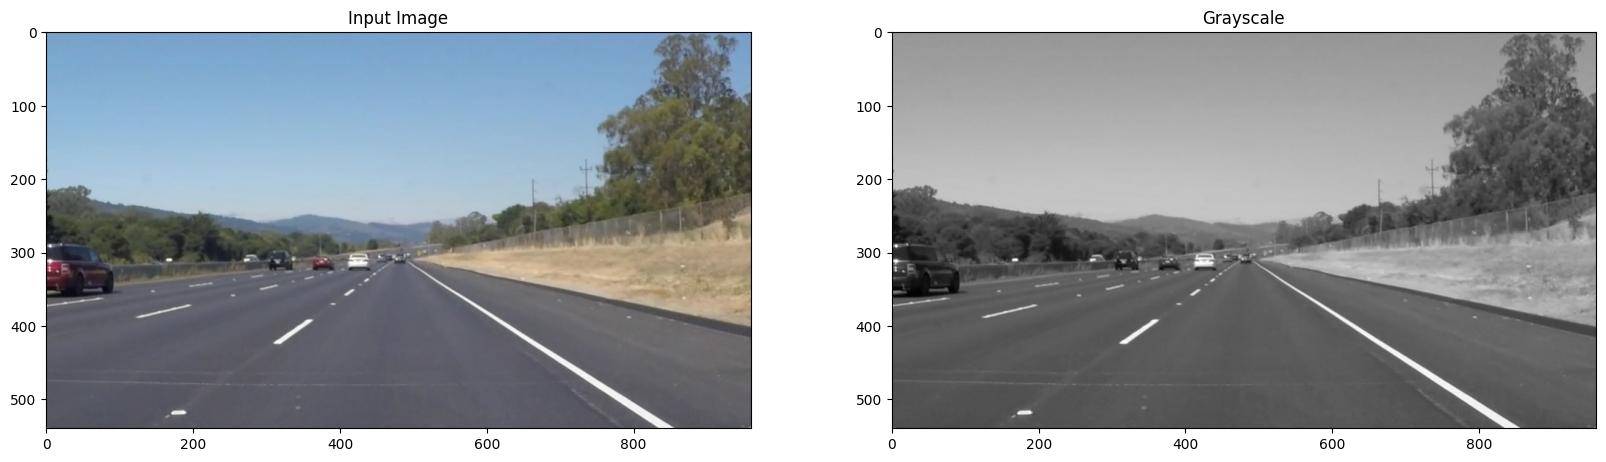

In [5]:
plt.figure(figsize = (20, 10))
#plt.figure(figsize = (15, 10))
plt.subplot(1,2,1); plt.imshow(img);plt.title('Input Image');
plt.subplot(1,2,2); plt.imshow(gray, cmap = 'gray'); plt.title('Grayscale');
plt.show()

In [6]:
threshold_value = 120  # Adjust threshold value as needed
_, threshold = cv2.threshold(gray, threshold_value, 255, cv2.THRESH_BINARY)

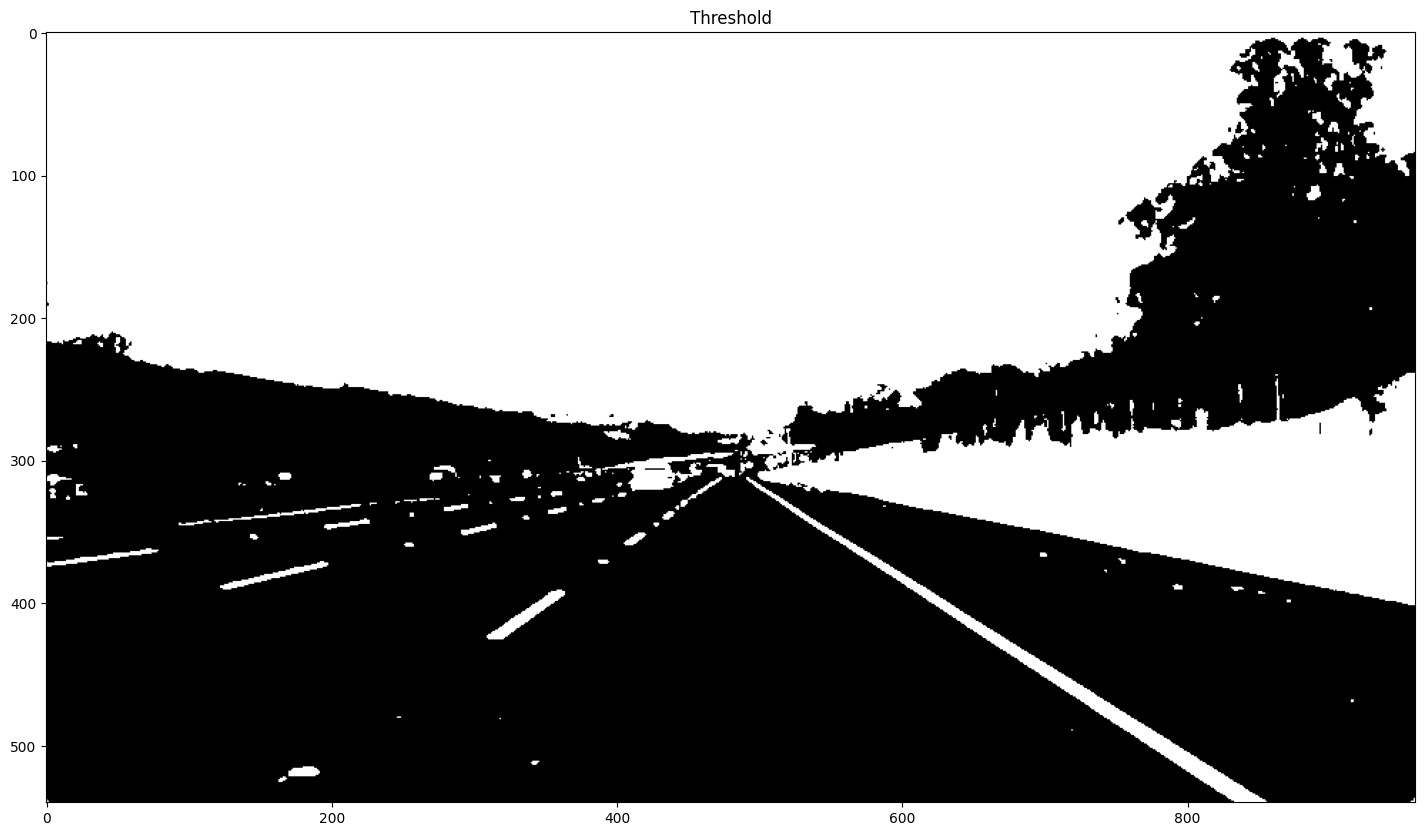

In [7]:
plt.figure(figsize = (20, 10))
plt.subplot(1,1,1); plt.imshow(threshold, cmap = 'gray'); plt.title('Threshold');
plt.show()

In [9]:
roi_vertices = np.array([[[100, 540],
                          [900, 540],
                          [515, 320],
                          [450, 320]]])

In [10]:
mask = np.zeros_like(threshold)  

In [11]:
if len(threshold.shape) > 2:
    channel_count = threshold.shape[2]  # 3 or 4 depending on the image.
    ignore_mask_color = (255,) * channel_count
else:
    ignore_mask_color = 255

In [12]:
cv2.fillPoly(mask, roi_vertices, ignore_mask_color)

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(540, 960), dtype=uint8)

In [13]:
roi = cv2.bitwise_and(threshold, mask)

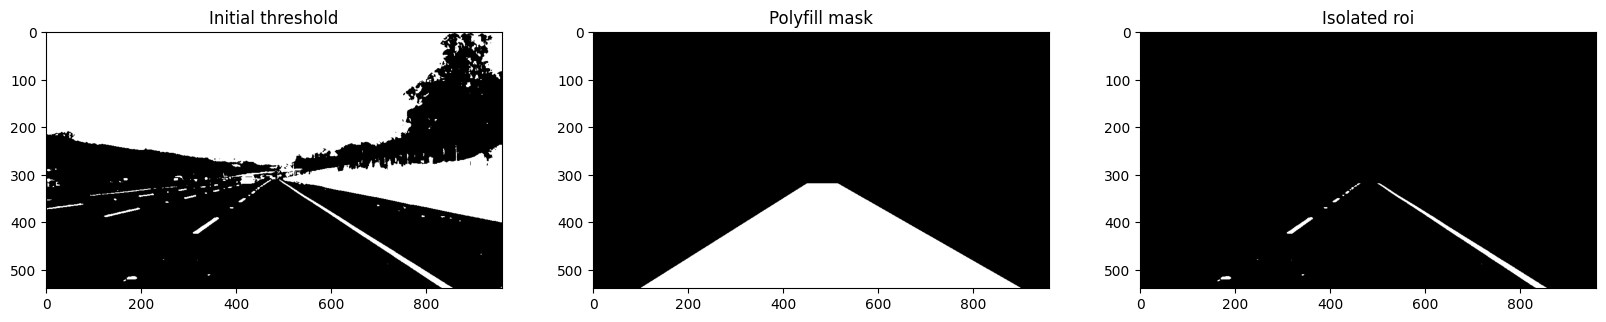

In [14]:
plt.figure(figsize = (20, 10))
plt.subplot(1,3,1); plt.imshow(threshold, cmap = 'gray'); plt.title('Initial threshold')
plt.subplot(1,3,2); plt.imshow(mask, cmap = 'gray');      plt.title('Polyfill mask')
plt.subplot(1,3,3); plt.imshow(roi, cmap = 'gray');       plt.title('Isolated roi');
plt.show()


In [15]:
edges = cv2.Canny(roi, 50, 150)

In [16]:
canny_blur = cv2.GaussianBlur(edges, (5, 5), 0)

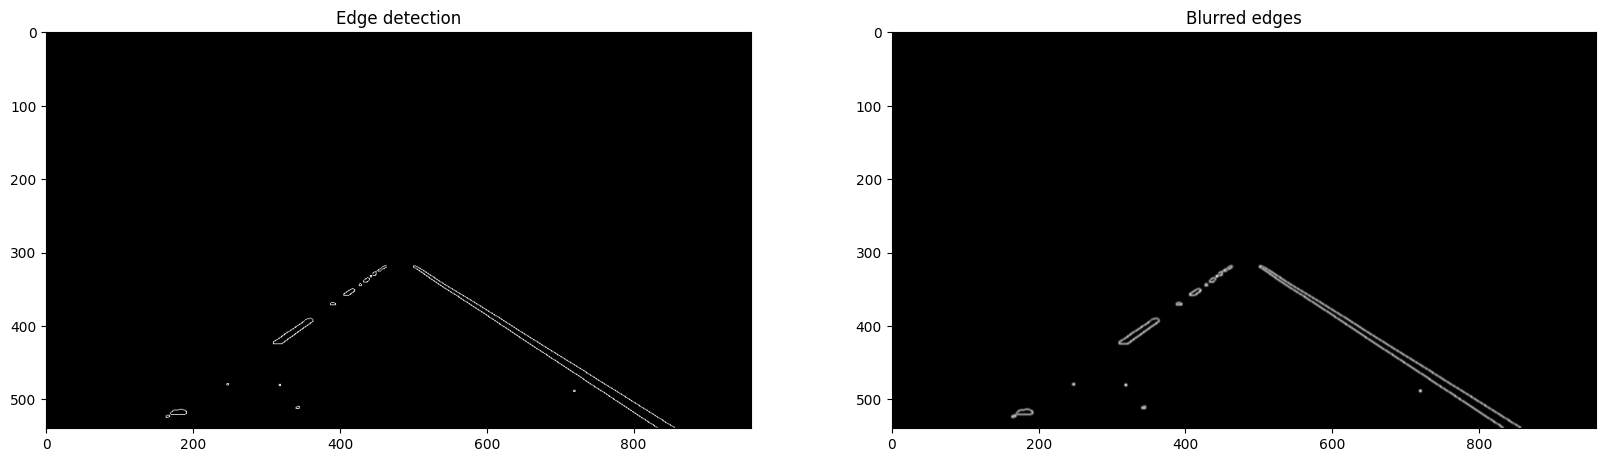

In [17]:
plt.figure(figsize = (20, 10))
plt.subplot(1,2,1); plt.imshow(edges, cmap = 'gray'); plt.title('Edge detection')
plt.subplot(1,2,2); plt.imshow(canny_blur, cmap = 'gray'); plt.title('Blurred edges');
plt.show()


In [18]:
def draw_lines(img, lines, color = [255, 0, 0], thickness = 2):
    """Utility for drawing lines."""
    if lines is not None:
        for line in lines:
            for x1,y1,x2,y2 in line:
                cv2.line(img, (x1, y1), (x2, y2), color, thickness)

In [19]:
rho = 1
theta = np.pi/180
threshold_hough = 20
min_line_length = 20
max_line_gap = 10

lines = cv2.HoughLinesP(canny_blur, rho, theta, threshold_hough, 
                        minLineLength=min_line_length, 
                        maxLineGap=max_line_gap)

Found 56 lines, including: [[498 322 833 539]]


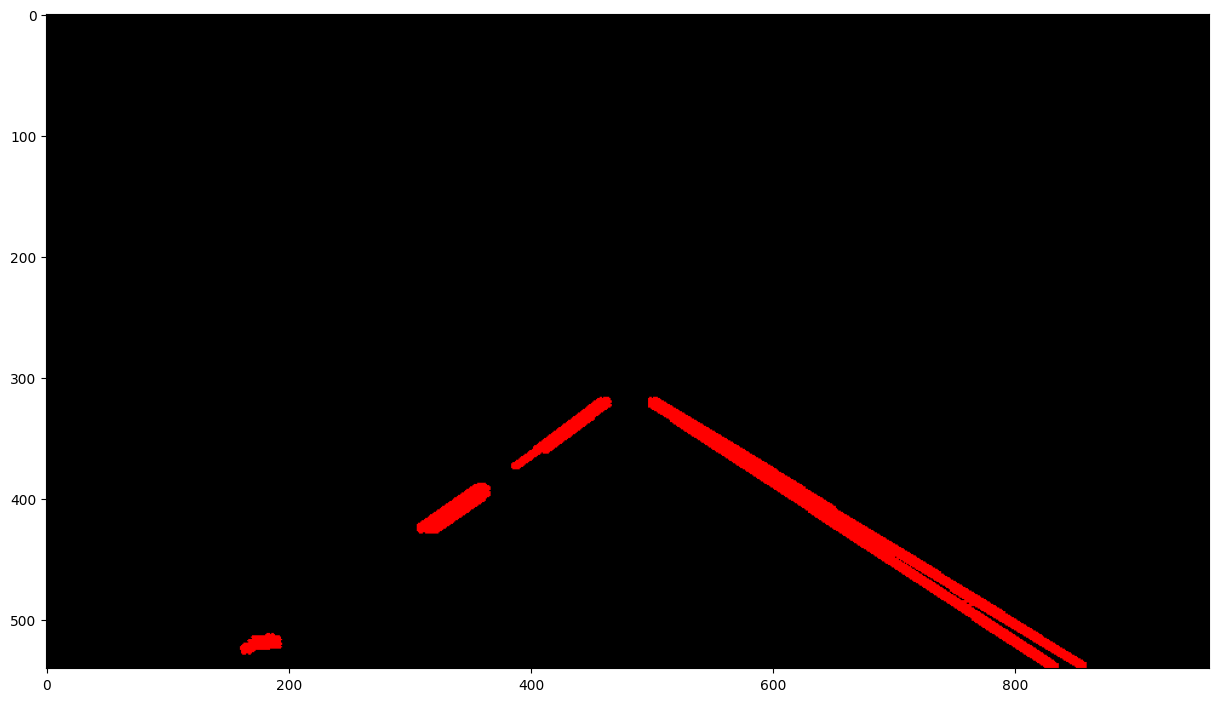

In [20]:
hough = np.zeros((img.shape[0], img.shape[1], 3), dtype = np.uint8)
draw_lines(hough, lines)

print("Found {} lines, including: {}".format(len(lines), lines[0]))
plt.figure(figsize = (15, 10)); plt.imshow(hough);
plt.show()


In [21]:
def separate_left_right_lines(lines):
    """Separate left and right lines depending on the slope."""
    left_lines = []
    right_lines = []
    if lines is not None:
        for line in lines:
            for x1, y1, x2, y2 in line:
                if x2 - x1 != 0:  # Avoid division by zero
                    slope = (y2 - y1) / (x2 - x1)
                    if slope < -0.5:  # Negative slope = left lane.
                        left_lines.append([x1, y1, x2, y2])
                    elif slope > 0.5:  # Positive slope = right lane.
                        right_lines.append([x1, y1, x2, y2])
    return left_lines, right_lines

def cal_avg(values):
    """Calculate average value."""
    if values is not None and len(values) > 0:
        return sum(values) / len(values)
    return 0

def extrapolate_lines(lines, upper_border, lower_border):
    """Extrapolate lines keeping in mind the lower and upper border intersections."""
    slopes = []
    consts = []
    
    if len(lines) > 0:
        for x1, y1, x2, y2 in lines:
            if x2 - x1 != 0:
                slope = (y2 - y1) / (x2 - x1)
                slopes.append(slope)
                c = y1 - slope * x1
                consts.append(c)
    
    if len(slopes) == 0 or len(consts) == 0:
        return [0, lower_border, 0, upper_border]
    
    avg_slope = cal_avg(slopes)
    avg_consts = cal_avg(consts)
    
    # Calculate average intersection at lower_border.
    if avg_slope != 0:
        x_lane_lower_point = int((lower_border - avg_consts) / avg_slope)
    else:
        x_lane_lower_point = 0
    
    # Calculate average intersection at upper_border.
    if avg_slope != 0:
        x_lane_upper_point = int((upper_border - avg_consts) / avg_slope)
    else:
        x_lane_upper_point = 0
    
    return [x_lane_lower_point, lower_border, x_lane_upper_point, upper_border]

In [22]:
roi_upper_border = 340
roi_lower_border = 540

In [23]:
lanes_img = np.zeros((img.shape[0], img.shape[1], 3), dtype = np.uint8)

In [24]:
lines_left, lines_right = separate_left_right_lines(lines)

In [25]:
lane_left = extrapolate_lines(lines_left, roi_upper_border, roi_lower_border)
lane_right = extrapolate_lines(lines_right, roi_upper_border, roi_lower_border)
draw_lines(lanes_img, [[lane_left]], thickness = 10)
draw_lines(lanes_img, [[lane_right]], thickness = 10)

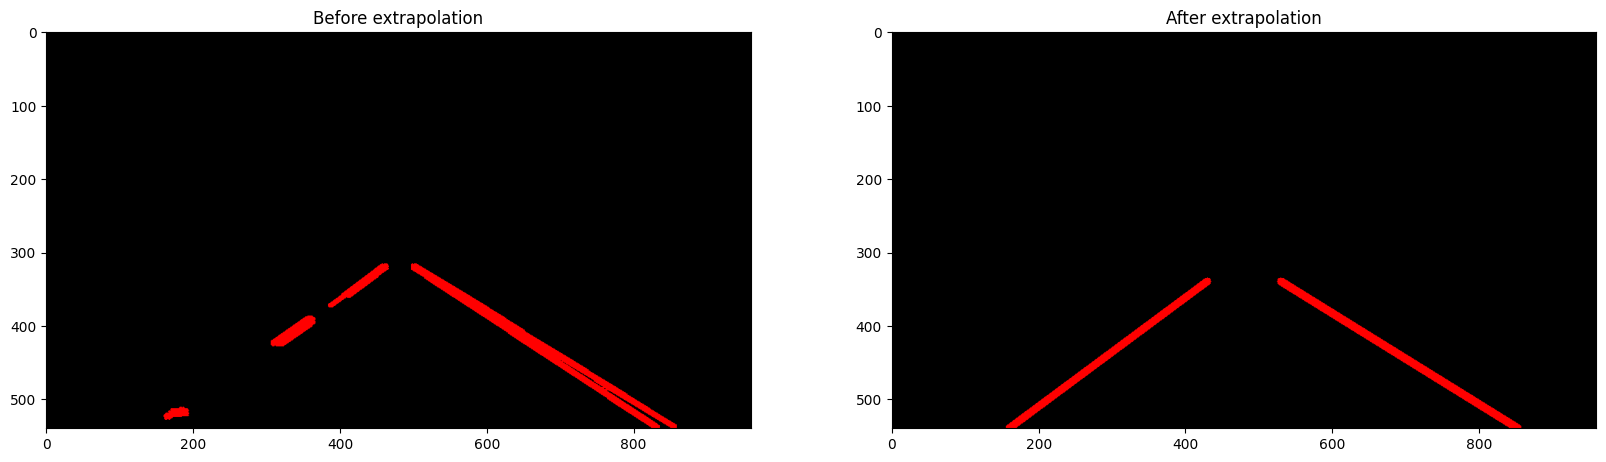

In [26]:
fig = plt.figure(figsize = (20, 20))
ax = fig.add_subplot(1, 2, 1); plt.imshow(hough); ax.set_title('Before extrapolation')
ax = fig.add_subplot(1, 2, 2); plt.imshow(lanes_img); ax.set_title('After extrapolation');
plt.show()